<a href="https://colab.research.google.com/github/QuanPhan78/thuchanhdeeplearning/blob/main/BaiThucHanhBuoi3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANN NHẬN DẠNG ẢNH CIFAR-10

# 1.Import thư viện

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt


#2.Load và xử lý dữ liệu CIFAR-10

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
x_train shape: (50000, 32, 32, 3)
x_test shape: (10000, 32, 32, 3)


#Chuẩn hóa dữ liệu — đưa giá trị pixel về [0, 1]

In [ ]:
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

#Flatten ảnh — ANN cần input 1 chiều (vì ANN không xử lý không gian 2D như CNN)

In [ ]:
# 32x32x3 = 3072 đặc trưng
x_train_flat = x_train.reshape(x_train.shape[0], -1)  # (50000, 3072)
x_test_flat  = x_test.reshape(x_test.shape[0], -1)    # (10000, 3072)

#3. Hiển thị 1 số ảnh mẫu

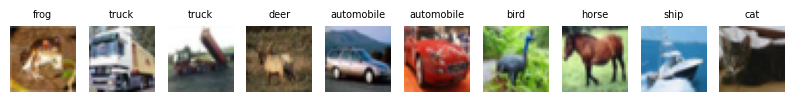

In [ ]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=7)
    plt.axis('off')
plt.show()

#4. Xây dựng mô hình ANN

In [ ]:
model = keras.Sequential([
    # Input layer
    keras.layers.Input(shape=(3072,)),

    # Hidden layer 1
    keras.layers.Dense(512, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    # Hidden layer 2
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    # Hidden layer 3
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),

    # Output layer — 10 lớp
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,741,962 (6.65 MB)

 Trainable params: 1,740,426 (6.64 MB)

 Non-trainable params: 1,536 (6.00 KB)

#5. cOMPILE MÔ HÌNH

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # y là số nguyên (0-9)
    metrics=['accuracy']
)

#6. HUẤN LUYỆN MÔ HÌNH

In [ ]:
history = model.fit(
    x_train_flat, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,   # 20% train dùng để validate
    verbose=1
)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.4887 - loss: 1.4290 - val_accuracy: 0.4805 - val_loss: 1.4402
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.4962 - loss: 1.4118 - val_accuracy: 0.5164 - val_loss: 1.3642
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.4923 - loss: 1.4164 - val_accuracy: 0.4951 - val_loss: 1.3999
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.4931 - loss: 1.4182 - val_accuracy: 0.5181 - val_loss: 1.3421
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.4955 - loss: 1.4100 - val_accuracy: 0.4776 - val_loss: 1.4668
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.4986 - loss: 1.4025 - val_accuracy: 0.5003 - val_loss: 1.3898
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.5012 - loss: 1.4009 - val_accuracy: 0.5220 - val_loss: 1.3396
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.4990 - loss: 1.4008 - 

#7. ĐÁNH GIÁ MÔ HÌNH

In [ ]:
test_loss, test_acc = model.evaluate(x_test_flat, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")


Test Accuracy: 46.89%
Test Loss:     1.5157


#8. VẼ BIỂU ĐỒ LOSS VÀ ACCURACY

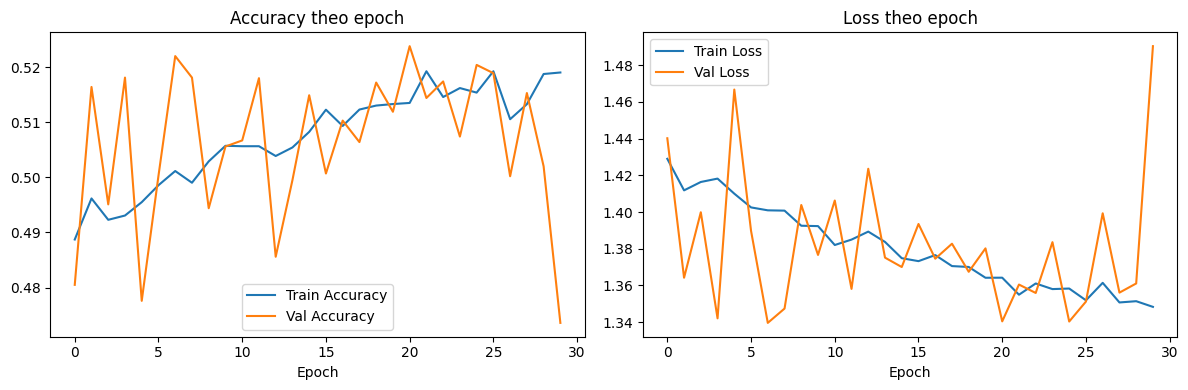

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Accuracy theo epoch')
ax1.set_xlabel('Epoch')
ax1.legend()

# Loss
ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss theo epoch')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

# 9. DỰ ĐOÁN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


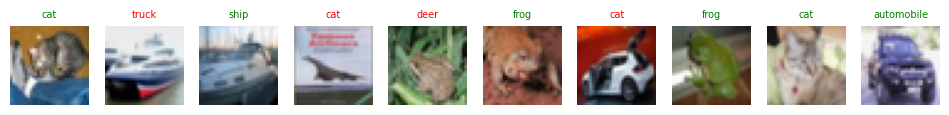

In [ ]:
# Dự đoán 10 ảnh đầu của test set
y_pred = np.argmax(model.predict(x_test_flat[:10]), axis=1)

plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_test[i])
    color = 'green' if y_pred[i] == y_test[i][0] else 'red'
    plt.title(class_names[y_pred[i]], fontsize=7, color=color)
    plt.axis('off')
plt.show()

# CNN NHẬN DẠNG CHỮ VIẾT SỐ

# 1. IMPORT THƯ VIỆN

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# 2.Load và xử lý dữ liệu MNIST

In [ ]:
# Load dữ liệu MNIST có sẵn trong keras
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Shape ban đầu:")
print("x_train:", x_train.shape)  # (60000, 28, 28)
print("x_test: ", x_test.shape)   # (10000, 28, 28)

# CNN cần input shape (batch, height, width, channels)
# MNIST là ảnh xám nên channels = 1
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test  = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

print("\nShape sau reshape:")
print("x_train:", x_train.shape)  # (60000, 28, 28, 1)
print("x_test: ", x_test.shape)   # (10000, 28, 28, 1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape ban đầu:
x_train: (60000, 28, 28)
x_test:  (10000, 28, 28)

Shape sau reshape:
x_train: (60000, 28, 28, 1)
x_test:  (10000, 28, 28, 1)


# 3.Hiển thị ảnh mẫu

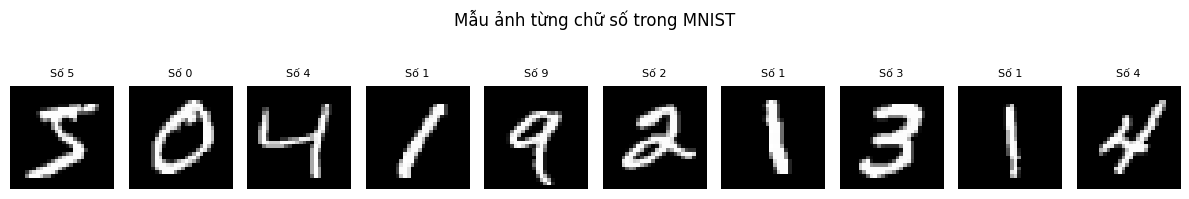

In [ ]:
class_names = [f'Số {i}' for i in range(10)]

plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=8)
    plt.axis('off')
plt.suptitle("Mẫu ảnh từng chữ số trong MNIST", y=1.05)
plt.tight_layout()
plt.show()

#4.Xây dựng mô hình CNN

In [ ]:
model = keras.Sequential([

    # =====================
    # BLOCK 1: Conv + Pool
    # =====================
    layers.Conv2D(32, kernel_size=(3,3), activation='relu',
                  padding='same', input_shape=(28, 28, 1)),
    # Output: (28, 28, 32)

    layers.Conv2D(32, kernel_size=(3,3), activation='relu', padding='same'),
    # Output: (28, 28, 32)

    layers.MaxPooling2D(pool_size=(2,2)),
    # Output: (14, 14, 32)

    layers.Dropout(0.25),

    # =====================
    # BLOCK 2: Conv + Pool
    # =====================
    layers.Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),
    # Output: (14, 14, 64)

    layers.Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),
    # Output: (14, 14, 64)

    layers.MaxPooling2D(pool_size=(2,2)),
    # Output: (7, 7, 64)

    layers.Dropout(0.25),

    # =====================
    # Flatten + Fully Connected
    # =====================
    layers.Flatten(),
    # Output: 7*7*64 = 3136

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # Output layer: 10 lớp (số 0–9)
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 871,658 (3.33 MB)

 Trainable params: 871,146 (3.32 MB)

 Non-trainable params: 512 (2.00 KB)

# 5. Compile mô hình

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6.Data Augmentation (tùy chọn, tăng độ chính xác)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,       # Xoay ảnh tối đa 10 độ
    zoom_range=0.1,          # Zoom 10%
    width_shift_range=0.1,   # Dịch ngang 10%
    height_shift_range=0.1   # Dịch dọc 10%
)

datagen.fit(x_train)

# 7. Huấn luyện mô hình

In [ ]:
# Callback: dừng sớm nếu không cải thiện
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# Huấn luyện với data augmentation
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=128),
    epochs=20,
    validation_data=(x_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 297s 628ms/step - accuracy: 0.9113 - loss: 0.2810 - val_accuracy: 0.9866 - val_loss: 0.0438
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 275s 587ms/step - accuracy: 0.9708 - loss: 0.0952 - val_accuracy: 0.9895 - val_loss: 0.0295
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 283s 603ms/step - accuracy: 0.9774 - loss: 0.0718 - val_accuracy: 0.9933 - val_loss: 0.0203
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 283s 603ms/step - accuracy: 0.9809 - loss: 0.0616 - val_accuracy: 0.9930 - val_loss: 0.0198
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 275s 587ms/step - accuracy: 0.9834 - loss: 0.0546 - val_accuracy: 0.9924 - val_loss: 0.0229
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 273s 582ms/step - accuracy: 0.9833 - loss: 0.0525 - val_accuracy: 0.9921 - val_loss: 0.0255
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 273s 582ms/step - accuracy: 0.9857 - loss: 0.0474 - val_accuracy: 0.9952 - val_loss: 0.0151
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 331s 601ms/step - accuracy: 0.9866 -

# 8. Đánh giá mô hình

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy : {test_acc*100:.2f}%")
print(f"📉 Test Loss     : {test_loss:.4f}")


✅ Test Accuracy : 99.56%
📉 Test Loss     : 0.0138


# 9. Vẽ biểu đồ Loss & Accuracy

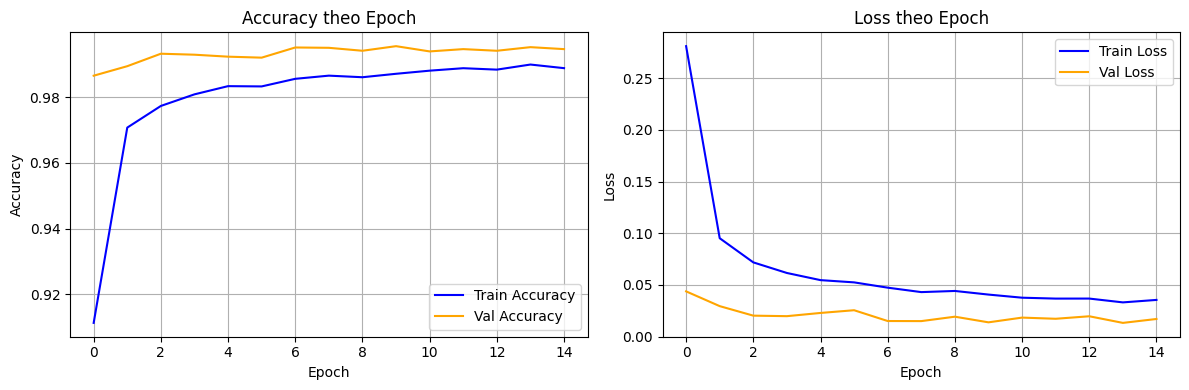

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
ax1.set_title('Accuracy theo Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'],     label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Val Loss',   color='orange')
ax2.set_title('Loss theo Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

#10.Dự đoán & Hiển thị kết quả

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


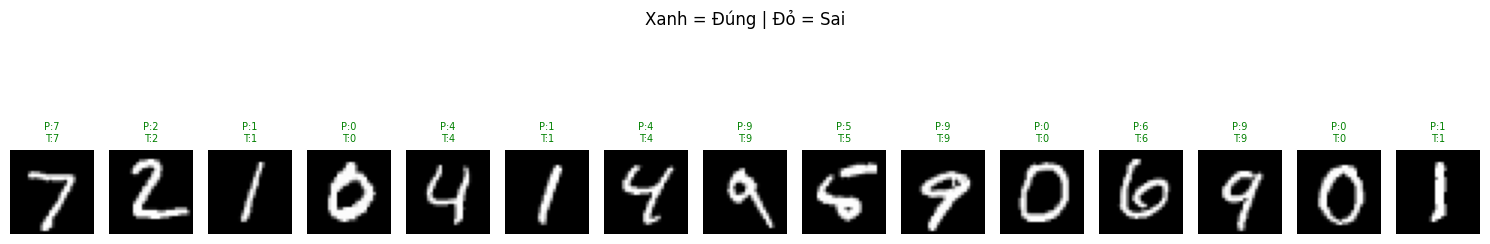

In [ ]:
# Dự đoán 15 ảnh đầu
y_pred_probs = model.predict(x_test[:15])
y_pred = np.argmax(y_pred_probs, axis=1)

plt.figure(figsize=(15, 3))
for i in range(15):
    plt.subplot(1, 15, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')

    true_label = y_test[i]
    pred_label = y_pred[i]
    color = 'green' if pred_label == true_label else 'red'

    plt.title(f"P:{pred_label}\nT:{true_label}",
              fontsize=7, color=color)
    plt.axis('off')

plt.suptitle("Xanh = Đúng | Đỏ = Sai", y=1.05)
plt.tight_layout()
plt.show()

#11.Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step


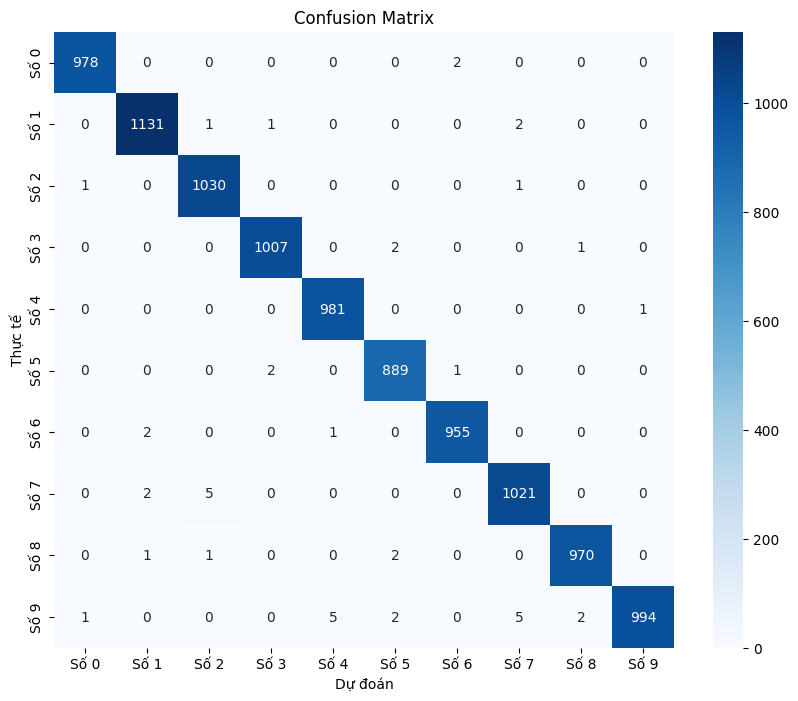

              precision    recall  f1-score   support

        Số 0       1.00      1.00      1.00       980
        Số 1       1.00      1.00      1.00      1135
        Số 2       0.99      1.00      1.00      1032
        Số 3       1.00      1.00      1.00      1010
        Số 4       0.99      1.00      1.00       982
        Số 5       0.99      1.00      0.99       892
        Số 6       1.00      1.00      1.00       958
        Số 7       0.99      0.99      0.99      1028
        Số 8       1.00      1.00      1.00       974
        Số 9       1.00      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_all = np.argmax(model.predict(x_test), axis=1)

cm = confusion_matrix(y_test, y_pred_all)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

print(classification_report(y_test, y_pred_all, target_names=class_names))

# UPLOAD ẢNH

📂 Chọn file ảnh để upload...


Saving hinh-dang-mau-nuoc-ve-tay-cho-thiet-ke-cua-ban-nen-sang-tao-trang-tri-thu-cong_379823-2033.avif to hinh-dang-mau-nuoc-ve-tay-cho-thiet-ke-cua-ban-nen-sang-tao-trang-tri-thu-cong_379823-2033.avif

📁 File: hinh-dang-mau-nuoc-ve-tay-cho-thiet-ke-cua-ban-nen-sang-tao-trang-tri-thu-cong_379823-2033.avif


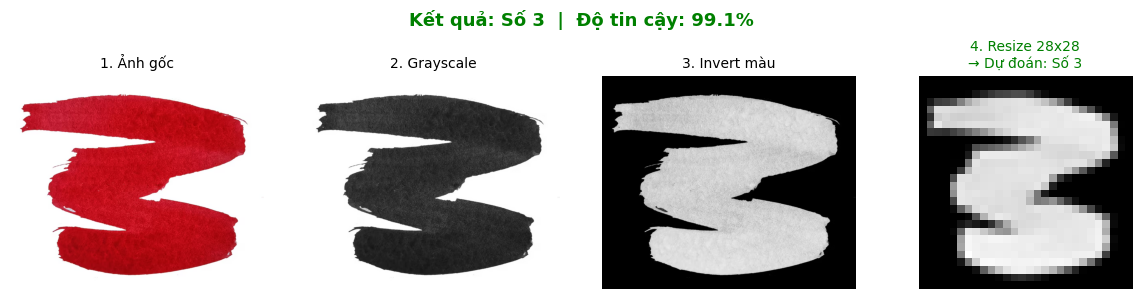


✅ Dự đoán : Số 3
📊 Độ tin cậy: 99.05%

📈 Xác suất từng số:
-----------------------------------
  Số 0:                                              0.0%
  Số 1:                                              0.0%
  Số 2:                                              0.0%
  Số 3: ███████████████████████████████████████     99.1% ← Dự đoán
  Số 4:                                              0.0%
  Số 5:                                              0.8%
  Số 6:                                              0.0%
  Số 7:                                              0.0%
  Số 8:                                              0.1%
  Số 9:                                              0.0%
-----------------------------------


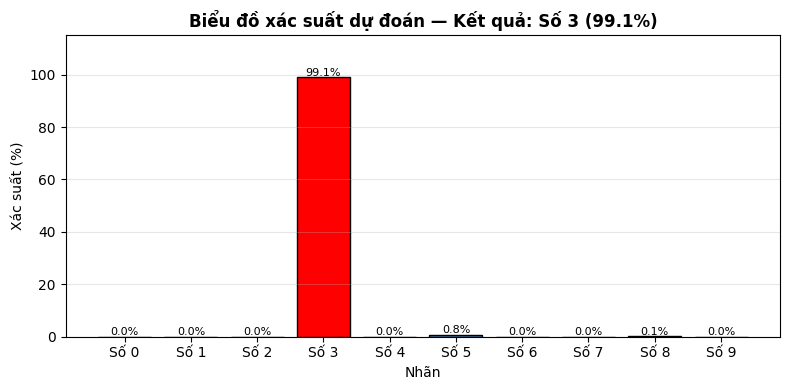

In [ ]:
# ============================================================
# BƯỚC 1: Import thư viện
# ============================================================
from google.colab import files
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# BƯỚC 2: Upload ảnh
# ============================================================
print("📂 Chọn file ảnh để upload...")
uploaded = files.upload()  # Sẽ xuất hiện nút "Choose Files"
# ============================================================
# BƯỚC 3: Xử lý ảnh + Dự đoán
# ============================================================
class_names = [f'Số {i}' for i in range(10)]

for filename in uploaded.keys():
    print(f"\n{'='*50}")
    print(f"📁 File: {filename}")
    print(f"{'='*50}")

    # --------------------------
    # Mở và xem ảnh gốc
    # --------------------------
    img_original = Image.open(filename)

    # --------------------------
    # Xử lý ảnh
    # --------------------------
    # Chuyển sang grayscale (ảnh xám)
    img_gray = img_original.convert('L')

    # Invert màu: nền trắng → nền đen, chữ đen → chữ trắng
    # (MNIST có nền đen, chữ trắng)
    img_inverted = ImageOps.invert(img_gray)

    # Resize về 28x28 (kích thước MNIST)
    img_resized = img_inverted.resize((28, 28))

    # Chuẩn hóa về [0, 1] và reshape
    img_array = np.array(img_resized).reshape(1, 28, 28, 1) / 255.0

    # --------------------------
    # Dự đoán
    # --------------------------
    pred = model.predict(img_array, verbose=0)
    label = np.argmax(pred)
    confidence = np.max(pred) * 100

    # --------------------------
    # Hiển thị ảnh các bước xử lý
    # --------------------------
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))

    axes[0].imshow(img_original)
    axes[0].set_title('1. Ảnh gốc', fontsize=10)
    axes[0].axis('off')

    axes[1].imshow(img_gray, cmap='gray')
    axes[1].set_title('2. Grayscale', fontsize=10)
    axes[1].axis('off')

    axes[2].imshow(img_inverted, cmap='gray')
    axes[2].set_title('3. Invert màu', fontsize=10)
    axes[2].axis('off')

    axes[3].imshow(img_resized, cmap='gray')
    axes[3].set_title(f'4. Resize 28x28\n→ Dự đoán: Số {label}',
                      fontsize=10, color='green')
    axes[3].axis('off')

    plt.suptitle(f'Kết quả: Số {label}  |  Độ tin cậy: {confidence:.1f}%',
                 fontsize=13, fontweight='bold', color='green')
    plt.tight_layout()
    plt.show()

    # --------------------------
    # In xác suất từng số
    # --------------------------
    print(f"\n✅ Dự đoán : Số {label}")
    print(f"📊 Độ tin cậy: {confidence:.2f}%")
    print(f"\n📈 Xác suất từng số:")
    print("-" * 35)
    for i, p in enumerate(pred[0]):
        bar = '█' * int(p * 40)
        marker = ' ← Dự đoán' if i == label else ''
        print(f"  Số {i}: {bar:<42} {p*100:5.1f}%{marker}")
    print("-" * 35)
# ============================================================
# BƯỚC 4 (Bonus): Vẽ biểu đồ xác suất dạng cột
# ============================================================
plt.figure(figsize=(8, 4))
colors = ['red' if i == label else 'steelblue' for i in range(10)]
bars = plt.bar(range(10), pred[0] * 100, color=colors, edgecolor='black')

# Thêm giá trị lên đầu mỗi cột
for bar, val in zip(bars, pred[0] * 100):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=8)

plt.xticks(range(10), [f'Số {i}' for i in range(10)])
plt.xlabel('Nhãn')
plt.ylabel('Xác suất (%)')
plt.title(f'Biểu đồ xác suất dự đoán — Kết quả: Số {label} ({confidence:.1f}%)',
          fontweight='bold')
plt.ylim(0, 115)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()